# **Day 64: Data Augmentation and Training Tricks**
*Module 10 - Deep Learning Foundations*

Deep networks are data-hungry; labelled data are scarce. **Data augmentation** creates realistic variations of training samples (rotations, flips, brightness changes, noise) so the model learns **invariances** instead of memorising. Together with a few other tricks (label smoothing, mixup, test-time augmentation, mixed precision), it often gives larger gains than a new architecture.

> Data augmentation creates new training examples by transforming existing ones (flips, rotations, brightness changes) in ways that do not change the label. Combined with training tricks, it reduces overfitting when data is limited.
>
> *Example:* A forest patch rotated by 90 degrees is still forest, so one labelled patch can become eight training examples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, copy
from torch.utils.data import Dataset, DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter
torch.manual_seed(64); rng = np.random.default_rng(64)

VEG = [0.04, 0.07, 0.05, 0.30]      # forest, cropland and grassland share ONE mean spectrum: only spatial texture separates them
SPECTRA = {"water": [0.06, 0.05, 0.03, 0.02], "forest": VEG, "cropland": VEG, "grassland": VEG,
           "urban": [0.12, 0.12, 0.13, 0.20], "bare_soil": [0.13, 0.15, 0.18, 0.24]}
CLASSES = list(SPECTRA)

def _norm(t): return (t - t.mean()) / (t.std() + 1e-9)

def make_patch(cls, size=32, r=rng):
    s = np.array(SPECTRA[cls]) * r.uniform(0.75, 1.25) * r.uniform(0.9, 1.1, 4)          # brightness + per-band variation
    yy, xx = np.mgrid[0:size, 0:size]
    if cls == "water": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 6))
    elif cls == "forest": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 0.8))      # fine, rough canopy
    elif cls == "cropland":
        a, per = r.uniform(0, np.pi), r.uniform(5, 10); tex = _norm(np.sin(2 * np.pi * (xx * np.cos(a) + yy * np.sin(a)) / per))   # field stripes
    elif cls == "grassland": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 3))       # smooth patches
    elif cls == "urban":
        b = r.integers(4, 8); tex = _norm((((xx // b) % 2) ^ ((yy // b) % 2)).astype(float))    # block grid
    else: tex = _norm(gaussian_filter(r.normal(size=(size, size)), 4))
    return (s[:, None, None] * (1 + r.uniform(0.15, 0.3) * tex[None]) + r.normal(0, 0.012, (4, size, size))).astype(np.float32)
def make_dataset(n, seed):
    r = np.random.default_rng(seed); return np.stack([make_patch(c, 32, r) for c in CLASSES for _ in range(n)]), np.repeat(np.arange(6), n)

## **1. Augmentations for Satellite Patches**

| Augmentation | Safe for nadir RS? | Why |
|---|---|---|
| 90-degree rotations, horizontal/vertical flips | **yes** | no canonical "up"; the 8 dihedral transforms preserve everything |
| Small arbitrary rotations, crops, scale | mostly | interpolation; careful with fixed GSD |
| Per-band brightness/contrast jitter | **yes, moderate** | illumination, atmosphere, sensor calibration differences |
| Gaussian noise, blur | yes | sensor noise, resampling |
| Cloud / haze / shadow simulation | yes, if clouds are expected at inference | robustness |
| Hue/colour jitter designed for RGB photos | **careful** | can destroy physically meaningful spectral relationships (e.g. NDVI) |
| Vertical flip for oblique / street-view photos | no | gravity matters there |

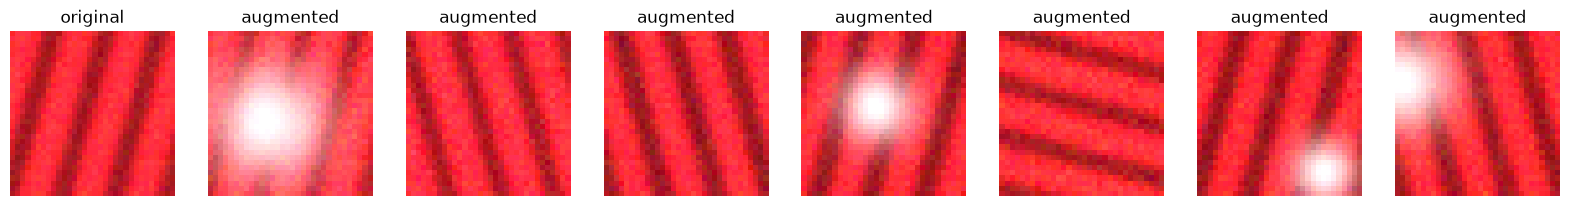

In [2]:
class Augment:
    def __init__(self, p_flip=0.5, rot90=True, brightness=0.15, band_jitter=0.05, noise=0.01, p_cloud=0.2, seed=0):
        self.p_flip, self.rot90, self.brightness, self.band_jitter, self.noise, self.p_cloud = p_flip, rot90, brightness, band_jitter, noise, p_cloud
        self.r = np.random.default_rng(seed)
    def __call__(self, x):                                                   # x: (bands, H, W) reflectance
        r = self.r
        if r.random() < self.p_flip: x = x[:, :, ::-1]
        if r.random() < self.p_flip: x = x[:, ::-1, :]
        if self.rot90: x = np.rot90(x, r.integers(4), axes=(1, 2))
        x = x * r.uniform(1 - self.brightness, 1 + self.brightness)                         # global illumination
        x = x * r.uniform(1 - self.band_jitter, 1 + self.band_jitter, (x.shape[0], 1, 1))  # per-band calibration
        x = x + r.normal(0, self.noise, x.shape)
        if r.random() < self.p_cloud:                                                         # soft synthetic cloud
            H, W = x.shape[1:]; cy, cx = r.uniform(0, H), r.uniform(0, W); rad = r.uniform(4, 12)
            yy, xx = np.mgrid[0:H, 0:W]; mask = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * rad ** 2))
            x = x * (1 - 0.8 * mask) + 0.4 * mask
        return np.ascontiguousarray(x, dtype=np.float32)

aug = Augment(seed=1)
p0 = make_patch("cropland")
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
axes[0].imshow(np.clip(p0[[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); axes[0].set_title("original")
for ax in axes[1:]:
    ax.imshow(np.clip(aug(p0)[[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); ax.set_title("augmented")
for ax in axes: ax.axis("off")
plt.show()

## **2. Augmentation Inside a Dataset (Training Only)**
Augment **on the fly** in `__getitem__`, so each epoch sees new variations. Never augment validation/test data (except for TTA, below).

In [3]:
class PatchDataset(Dataset):
    def __init__(self, X, y, mean, std, transform=None):
        self.X, self.y, self.mean, self.std, self.transform = X, y, mean, std, transform
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        x = self.X[i] if self.transform is None else self.transform(self.X[i])
        return torch.tensor((x - self.mean) / self.std, dtype=torch.float32), int(self.y[i])

class SmallCNN(nn.Module):
    def __init__(self, in_ch=4, n=6):
        super().__init__()
        blk = lambda ci, co: nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(), nn.MaxPool2d(2))
        self.f = nn.Sequential(blk(in_ch, 32), blk(32, 64), blk(64, 128)); self.h = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n))
    def forward(self, x): return self.h(self.f(x))

X_te, y_te = make_dataset(150, seed=99)
def run(n_per_class, transform, epochs=40, label_smoothing=0.0, mixup=0.0, seed=0):
    X_tr, y_tr = make_dataset(n_per_class, seed=seed + 1)
    mean, std = X_tr.mean((0, 2, 3), keepdims=True)[0], X_tr.std((0, 2, 3), keepdims=True)[0]
    dl = DataLoader(PatchDataset(X_tr, y_tr, mean, std, transform), batch_size=32, shuffle=True)
    torch.manual_seed(seed); model = SmallCNN(); opt = torch.optim.AdamW(model.parameters(), 1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            if mixup > 0:                                                # mixup: convex combination of pairs of samples and labels
                lam = np.random.default_rng(ep).beta(mixup, mixup); perm = torch.randperm(len(yb))
                xb = lam * xb + (1 - lam) * xb[perm]
                loss = lam * loss_fn(model(xb), yb) + (1 - lam) * loss_fn(model(xb), yb[perm])
            else:
                loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    model.eval(); Xn = torch.tensor((X_te - mean) / std)
    with torch.no_grad(): return (model(Xn).argmax(1).numpy() == y_te).mean(), model, mean, std

## **3. The Effect of Augmentation With Few Labels**

                            no augmentation  flips + rot90  \
labelled patches per class                                   
10                                    0.929          0.950   
30                                    0.986          0.993   
100                                   0.986          0.998   

                            geometric + radiometric + clouds  
labelled patches per class                                    
10                                                     0.897  
30                                                     0.962  
100                                                    0.999  


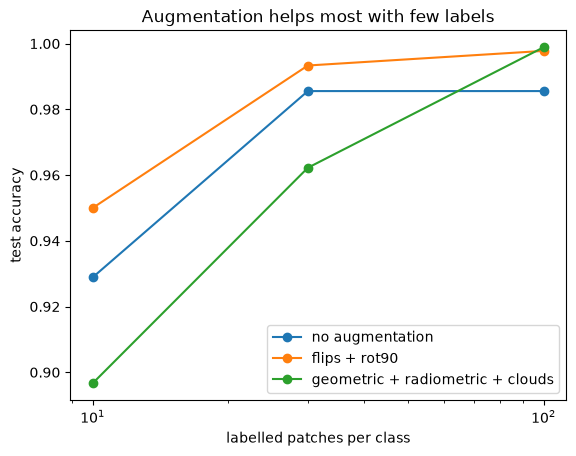

In [4]:
rows = []
for n in [10, 30, 100]:
    a_plain = run(n, None)[0]; a_geo = run(n, Augment(brightness=0, band_jitter=0, noise=0, p_cloud=0))[0]; a_full = run(n, Augment())[0]
    rows.append({"labelled patches per class": n, "no augmentation": a_plain, "flips + rot90": a_geo, "geometric + radiometric + clouds": a_full})
res = pd.DataFrame(rows).set_index("labelled patches per class"); print(res.round(3)); res.plot(marker="o", logx=True, title="Augmentation helps most with few labels"); plt.ylabel("test accuracy"); plt.show()

## **4. Robustness to Conditions Not in the Training Data**
Test on darker images with clouds (as in a hazy monsoon scene). The radiometric/cloud augmentations make the model robust to them.

In [5]:
harsh = Augment(p_flip=0, rot90=False, brightness=0.0, band_jitter=0.0, noise=0.01, p_cloud=1.0, seed=5)
X_harsh = np.stack([harsh(x) * 0.8 for x in X_te])
for name, tf in [("no augmentation", None), ("full augmentation", Augment())]:
    _, m, mean, std = run(30, tf)
    with torch.no_grad():
        acc_clean = (m(torch.tensor((X_te - mean) / std)).argmax(1).numpy() == y_te).mean()
        acc_harsh = (m(torch.tensor((X_harsh - mean) / std)).argmax(1).numpy() == y_te).mean()
    print(f"{name:<18} clean test {acc_clean:.3f} | darker + cloudy test {acc_harsh:.3f}")

no augmentation    clean test 0.986 | darker + cloudy test 0.677


full augmentation  clean test 0.962 | darker + cloudy test 0.891


## **5. Label Smoothing, Mixup and Test-Time Augmentation**
- **Label smoothing** (Szegedy et al., 2016): targets become 0.9 for the true class and 0.1/(K-1) for others; reduces over-confidence.
- **Mixup** (Zhang et al., 2018): train on convex combinations of pairs of images and their labels.
- **Test-time augmentation (TTA)**: average predictions over the 8 flips/rotations of each test patch.

In [6]:
rows = {}
rows["baseline + augmentation"] = run(30, Augment())[0]
rows["+ label smoothing 0.1"] = run(30, Augment(), label_smoothing=0.1)[0]
rows["+ mixup (alpha 0.4)"] = run(30, Augment(), mixup=0.4)[0]
acc_base, model_b, mean_b, std_b = run(30, Augment())
def tta_predict(model, X):
    Xt = torch.tensor((X - mean_b) / std_b); probs = 0
    with torch.no_grad():
        for k in range(4):
            for flip in [False, True]:
                v = torch.rot90(Xt, k, dims=(2, 3)); v = torch.flip(v, dims=(3,)) if flip else v
                probs = probs + torch.softmax(model(v), 1)
    return (probs / 8).argmax(1).numpy()
rows["+ test-time augmentation (8 dihedral views)"] = (tta_predict(model_b, X_te) == y_te).mean()
pd.Series(rows, name="test accuracy (30 labels per class)").round(3)

baseline + augmentation                        0.962
+ label smoothing 0.1                          0.960
+ mixup (alpha 0.4)                            0.988
+ test-time augmentation (8 dihedral views)    0.963
Name: test accuracy (30 labels per class), dtype: float64

(Differences of ~1% between these tricks are within seed-to-seed noise at this data size; evaluate several seeds before claiming a gain, Day 42.)

# **Part 2: Going Deeper**

### Augmentations that break the physics
Strong per-band colour jitter changes **ratios between bands**, so spectral indices (NDVI) and class signatures shift. If the class depends on spectral shape (e.g. stressed vs healthy crop), aggressive band jitter can teach the model to ignore exactly the signal we need.

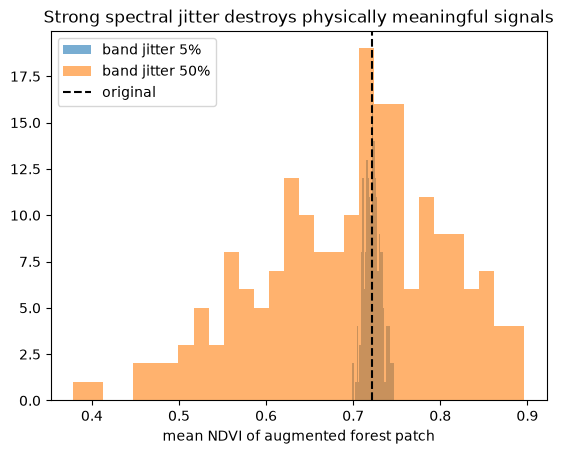

In [7]:
def ndvi(x): return (x[3] - x[2]) / (x[3] + x[2] + 1e-6)
base_patch = make_patch("forest")
mild = [ndvi(Augment(band_jitter=0.05, p_cloud=0, seed=s)(base_patch)).mean() for s in range(200)]
strong = [ndvi(Augment(band_jitter=0.5, p_cloud=0, seed=s)(base_patch)).mean() for s in range(200)]
plt.hist(mild, bins=30, alpha=0.6, label="band jitter 5%"); plt.hist(strong, bins=30, alpha=0.6, label="band jitter 50%")
plt.axvline(ndvi(base_patch).mean(), c="k", ls="--", label="original"); plt.xlabel("mean NDVI of augmented forest patch"); plt.legend(); plt.title("Strong spectral jitter destroys physically meaningful signals"); plt.show()

### Mixed precision and gradient accumulation (for larger models on GPUs)
```python
scaler = torch.amp.GradScaler("cuda")
for xb, yb in loader:
    with torch.autocast(device_type="cuda", dtype=torch.float16):   # forward in half precision: ~2x faster, half memory
        loss = loss_fn(model(xb), yb) / accum_steps
    scaler.scale(loss).backward()
    if (step + 1) % accum_steps == 0:                                 # gradient accumulation: effective batch = batch x accum_steps
        scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
```

### Libraries
`torchvision.transforms.v2`, **Albumentations** and **Kornia** (GPU augmentations) handle multi-band images and apply the **same** geometric transform to an image and its mask (essential for segmentation, Day 65). TorchGeo provides remote-sensing-specific augmentations.

## **Practice Problems**
1. Train with each augmentation alone (only flips, only brightness, only noise, only clouds) at 30 labels per class. Which helps most here?
2. Implement **cutmix**: paste a random rectangle from another image and mix labels by area.
3. Run the baseline and the full-augmentation model with 3 seeds each at 30 labels per class; report mean +/- sd.
4. *(Advanced)* Make the augmentation **consistent for image and mask** (same flips/rotations) for a segmentation pair, and verify with a test mask.

In [8]:
# Solution 1
singles = {"flips/rot90 only": Augment(brightness=0, band_jitter=0, noise=0, p_cloud=0), "brightness only": Augment(p_flip=0, rot90=False, band_jitter=0, noise=0, p_cloud=0),
           "noise only": Augment(p_flip=0, rot90=False, brightness=0, band_jitter=0, noise=0.02, p_cloud=0), "clouds only": Augment(p_flip=0, rot90=False, brightness=0, band_jitter=0, noise=0, p_cloud=0.5)}
print({k: round(float(run(30, v)[0]), 3) for k, v in singles.items()})
# Solution 2
def cutmix(xb, yb, alpha=1.0, r=np.random.default_rng(0)):
    lam = r.beta(alpha, alpha); H, W = xb.shape[2:]; ch, cw = int(H * np.sqrt(1 - lam)), int(W * np.sqrt(1 - lam))
    cy, cx = r.integers(H), r.integers(W); y1, y2, x1, x2 = max(cy - ch // 2, 0), min(cy + ch // 2, H), max(cx - cw // 2, 0), min(cx + cw // 2, W)
    perm = torch.randperm(len(yb)); xb = xb.clone(); xb[:, :, y1:y2, x1:x2] = xb[perm, :, y1:y2, x1:x2]
    lam_adj = 1 - (y2 - y1) * (x2 - x1) / (H * W); return xb, yb, yb[perm], lam_adj
xb_ = torch.randn(4, 4, 32, 32); out = cutmix(xb_, torch.tensor([0, 1, 2, 3])); print("cutmix label weight of the original:", round(out[3], 3))
# Solution 3
for name, tf in [("no augmentation", None), ("full augmentation", Augment())]:
    a = [run(30, tf, seed=s)[0] for s in range(3)]; print(f"{name:<18} {np.mean(a):.3f} +/- {np.std(a):.3f}")
# Solution 4
def paired_aug(img, mask, r):
    k = r.integers(4); flip = r.random() < 0.5
    img, mask = np.rot90(img, k, axes=(1, 2)), np.rot90(mask, k)
    if flip: img, mask = img[:, :, ::-1], mask[:, ::-1]
    return np.ascontiguousarray(img), np.ascontiguousarray(mask)
m0 = np.zeros((32, 32), int); m0[5:10, 20:30] = 1; i0 = np.repeat(m0[None].astype(float), 4, 0)
i1, m1 = paired_aug(i0, m0, np.random.default_rng(3)); print("image and mask still aligned:", np.array_equal(i1[0] > 0.5, m1 == 1))

{'flips/rot90 only': 0.993, 'brightness only': 0.986, 'noise only': 0.851, 'clouds only': 0.986}
cutmix label weight of the original: 0.859


no augmentation    0.984 +/- 0.002


full augmentation  0.962 +/- 0.012
image and mask still aligned: True


## **Key References**
- Shorten, C., & Khoshgoftaar, T. M. (2019). A survey on image data augmentation for deep learning. *Journal of Big Data*, 6, 60.
- Zhang, H., Cisse, M., Dauphin, Y. N., & Lopez-Paz, D. (2018). mixup: Beyond empirical risk minimization. *ICLR 2018*.
- Yun, S. et al. (2019). CutMix: Regularization strategy to train strong classifiers with localizable features. *ICCV 2019*.
- Szegedy, C., Vanhoucke, V., Ioffe, S., Shlens, J., & Wojna, Z. (2016). Rethinking the inception architecture for computer vision. *CVPR 2016* (label smoothing).
- Buslaev, A. et al. (2020). Albumentations: Fast and flexible image augmentations. *Information*, 11(2), 125.
- Micikevicius, P. et al. (2018). Mixed precision training. *ICLR 2018*.